# 선문대학교 컴퓨터공학부
# 2022243101 최완우

### 6.13 사이킷런을 이용한 서포트 벡터 머신 사용하기

데이터 셋 : 'https://github.com/dknife/ML/raw/main/data/'

In [1]:
import pandas as pd
import numpy as np
data_loc = 'https://github.com/dknife/ML/raw/main/data/'
df = pd.read_csv(data_loc + 'two_classes.csv')
df.tail(5)

,x1,x2,y
995,2.664896,-33.240534,0
996,-2.019928,5.687221,1
997,-4.634470,5.102681,1
998,1.426275,-47.015037,0
999,1.988053,24.930404,0


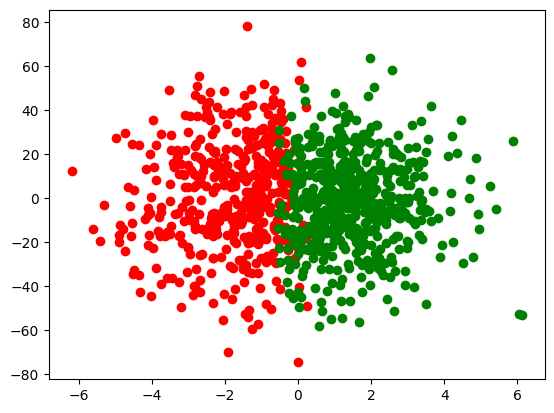

In [2]:
df_positive = df[df['y'] > 0]
df_negative = df[df['y'] == 0]
import matplotlib.pyplot as plt
plt.scatter(df_positive['x1'], df_positive['x2'], color = 'r')
plt.scatter(df_negative['x1'], df_negative['x2'], color = 'g') 

In [5]:
from sklearn.svm import LinearSVC
X = df[['x1', 'x2']].to_numpy()
y = df['y']
svm_simple = LinearSVC(C = 1, loss = 'hinge')
svm_simple.fit(X, y)

C:\Users\최완우\AppData\Roaming\Python\Python313\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,penalty,'l2'
,loss,'hinge'
,dual,'auto'
,tol,0.0001
,C,1
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


In [6]:
svm_simple.predict([[0.12, 0.56], [-4, 40], [0, 40], [5, 20]])

array([0, 1, 0, 0])

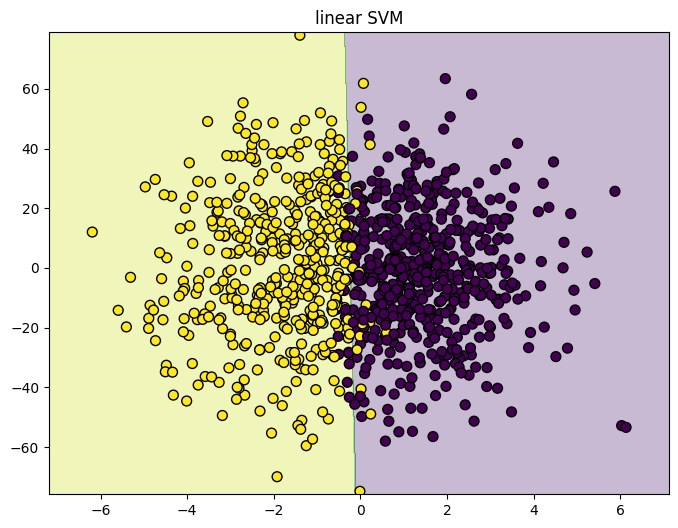

In [19]:
import numpy as np

# 결정 경계 시각화
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = svm_simple.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s=50)
plt.title('linear SVM')
plt.show()

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

svm_std = Pipeline([
    ("Std", StandardScaler()),
    ("lsvm", LinearSVC(C= 1, loss = 'hinge')),
])
svm_std.fit(X, y)

,steps,"[('Std', ...), ('lsvm', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,loss,'hinge'
,dual,'auto'
,tol,0.0001


In [21]:
from sklearn.preprocessing import PolynomialFeatures
svm_poly = Pipeline([
    ("std", StandardScaler()),
    ("poly_inputs", PolynomialFeatures(degree = 5)),
    ('lsmv', LinearSVC(C = 0.01, loss = 'hinge'))
])
svm_poly.fit(X, y)
viz = DecisionViz(svm_poly, title = 'polynomial feature SVM')
viz.draw(X, y)

C:\Users\최완우\AppData\Roaming\Python\Python313\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


NameError: name 'DecisionViz' is not defined